In [38]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from scipy.stats import mannwhitneyu

from utils import *

## Load anonymized dataframe of candidate accounts
Columns:
* `src-poster`: anonymous integer ID from the Smith et al. "A Blue Start" dataset
* `tgt_post`: number of reposts by the account before September 15, 2025
* `count(src_user)`: account's follower count
* `reposts_x_followers`: product of the account's follower count and repost count ("reach score")

The known attention brokers in this dataset, by rank order in terms of zero-indexed reach score, are 1, 6, 7, 9, 10, 14, 51, 69, 73, and 80.

In [12]:
df_users = pd.read_csv('candidate_accounts_anon_raw_by_20250915.csv')
attn_brokers = set([1, 6, 7, 9, 10, 14, 51, 69, 73, 80]) 
non_abs = set(range(100)) - attn_brokers

In [13]:
df_users.head(5)

,Unnamed: 0,src_poster,tgt_post,count(src_user),reposts_x_followers
0,1267415,3050,91834,154772,14213331848
1,1620608,295,31172,370132,11537754704
2,1682876,6563,26670,359691,9592958970
3,1822662,3117,87540,100942,8836462680
4,789702,22689,156770,54885,8604321450


In [14]:
users_ab = df_users.iloc[list(attn_brokers)]
users_non = df_users.iloc[list(non_abs)]

## Create plots comparing attention brokers' and non-attention brokers' repost/follower counts and reach scores.
We also use a [Mann-Whitney U Test](https://projecteuclid.org/journals/annals-of-mathematical-statistics/volume-18/issue-1/On-a-Test-of-Whether-one-of-Two-Random-Variables/10.1214/aoms/1177730491.full) to determine whether attention brokers' repost/follower counts and reach scores are stochastically {greater than / less than} the corresponding quantities for non-attention brokers.

The U Test is not significant for repost count but is significant for both follower count and reach score, indicating that attention brokers' follower counts ($p=0.0089$) and log scaled reach scores ($p=0.021$) are stochastically larger than non-attention brokers'.

MannwhitneyuResult(statistic=np.float64(328.0), pvalue=np.float64(0.08253885776024929))


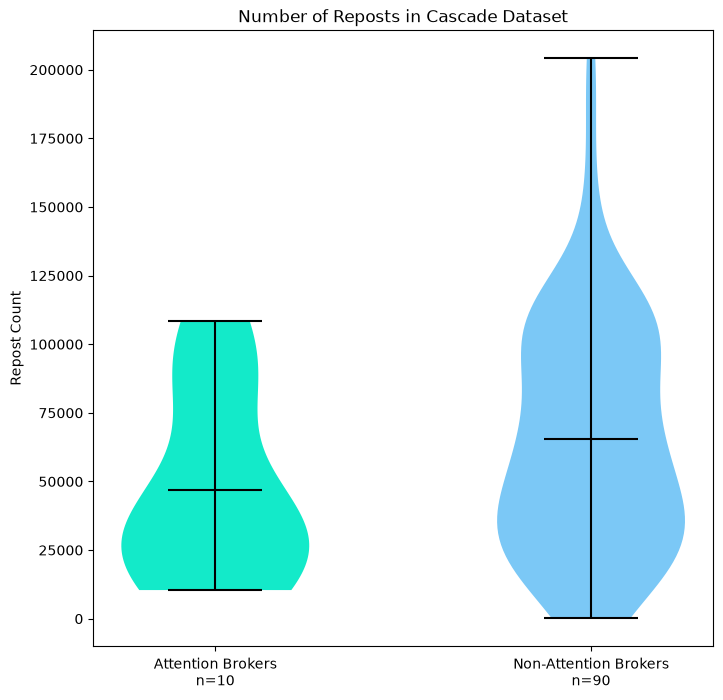

In [19]:
plt.rcParams['figure.figsize'] = (8, 8)
plt.violinplot(
    [users_ab['tgt_post'], users_non['tgt_post']], 
    [1, 2],
    showmeans=True, 
    showextrema=True, 
    facecolor=['xkcd:aqua', 'xkcd:lightblue'],
    linecolor='black',
)

plt.title("Number of Reposts in Cascade Dataset")
plt.xticks([1, 2], [f'Attention Brokers\nn={len(users_ab)}', f'Non-Attention Brokers\nn={len(users_non)}'])
plt.ylabel("Repost Count")
print(mannwhitneyu(users_ab['tgt_post'], users_non['tgt_post'], method='exact', alternative='less'))
plt.savefig('./new_figs/reposts_in_cascade_dataset.pdf')

MannwhitneyuResult(statistic=np.float64(654.0), pvalue=np.float64(0.008873209789953035))


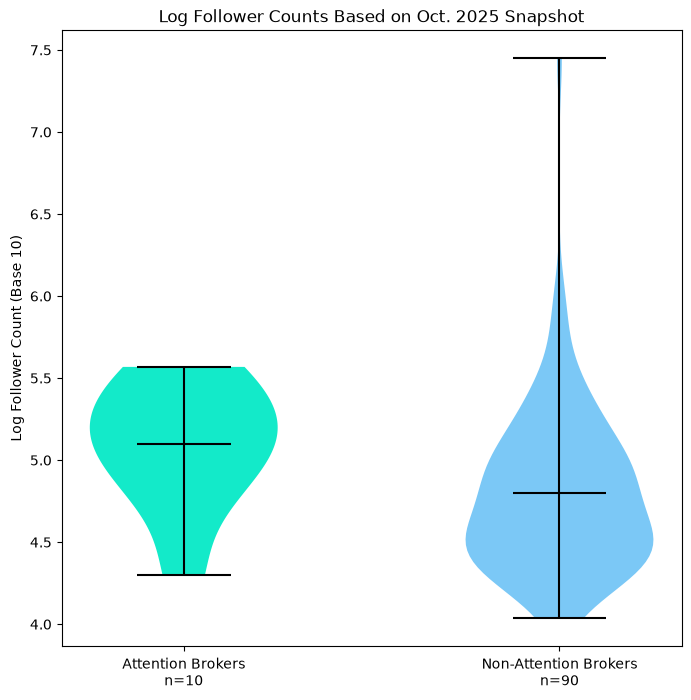

In [20]:
plt.rcParams['figure.figsize'] = (8, 8)
plt.violinplot(
    [np.log10(users_ab['count(src_user)']), np.log10(users_non['count(src_user)'])], 
    [1, 2],
    showmeans=True, 
    showextrema=True, 
    facecolor=['xkcd:aqua', 'xkcd:lightblue'],
    linecolor='black',
)

plt.title("Log Follower Counts Based on Oct. 2025 Snapshot")
plt.xticks([1, 2], [f'Attention Brokers\nn={len(users_ab)}', f'Non-Attention Brokers\nn={len(users_non)}'])
plt.ylabel("Log Follower Count (Base 10)")
print(mannwhitneyu(users_ab['count(src_user)'], users_non['count(src_user)'], method='exact', alternative='greater'))
plt.savefig('./new_figs/followers_cascade_dataset.pdf')

MannwhitneyuResult(statistic=np.float64(625.0), pvalue=np.float64(0.02189319290857668))


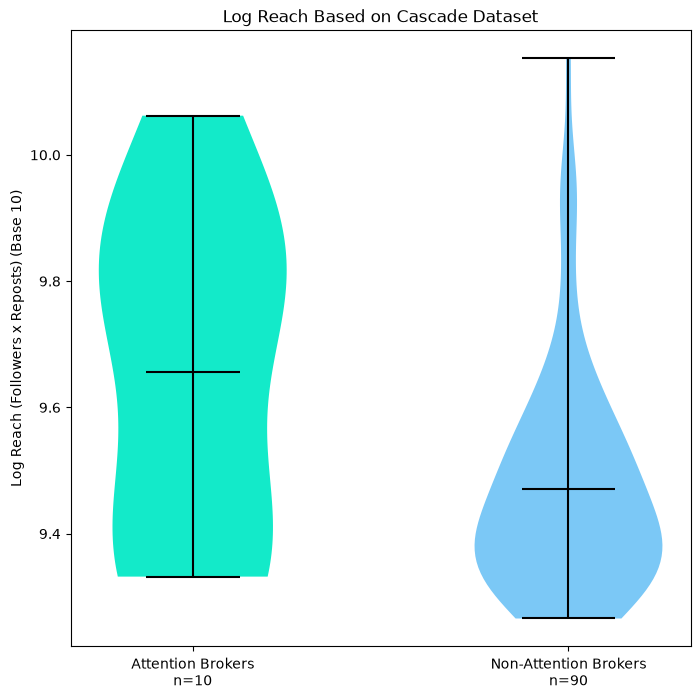

In [21]:
plt.rcParams['figure.figsize'] = (8, 8)
plt.violinplot(
    [np.log10(users_ab['reposts_x_followers']), np.log10(users_non['reposts_x_followers'])], 
    [1, 2],
    showmeans=True, 
    showextrema=True, 
    facecolor=['xkcd:aqua', 'xkcd:lightblue'],
    linecolor='black',
)

plt.title("Log Reach Based on Cascade Dataset")
plt.xticks([1, 2], [f'Attention Brokers\nn={len(users_ab)}', f'Non-Attention Brokers\nn={len(users_non)}'])
plt.ylabel("Log Reach (Followers x Reposts) (Base 10)")
print(mannwhitneyu(users_ab['reposts_x_followers'], users_non['reposts_x_followers'], method='exact', alternative='greater'))
plt.savefig('./new_figs/reach_distributions.pdf')

## Parsing DiD2S output from R script
The following code parses the output from the final analysis stage (two-stage differences-in-differences and significance testing for attention brokerage criteria).

Then we collate results and compare effect sizes at t=1 relative to repost for attention brokers and non-attention brokers.

In [22]:
def parse_file(lines_in):
    """
    Given a file of output from the R script panel_did2s.R, parse the output to determine the following quantities:

    * account ID
    * account status
    * number of control accounts studied
    * number of reposts studied
    * whether attention brokerage criteria C1-C4 were met
    * effect size for followers of the candidate account at t = 1
    * attention broker status (True/False)
    * number of failed attention brokerage criteria

    The relevant information will be returned in a dictionary. 
    Not all information may be present if output is truncated due to a lack of reposts or insufficient data for analysis.
    """
    acct_num = lines_in[1]

    if len(lines_in) < 3:
        return {
            'acct_num': acct_num,
            'status': 'no_json',
        }

    offset = 0
    if lines_in[4] == '"scaling controls down to 5000"':
        n_controls = 5000
        offset += 15

    else:
        n_controls = int(lines_in[3])

    if len(lines_in) < 7:
        return {
            'acct_num': acct_num,
            'status': 'no_analysis',
        }

    if lines_in[6 + offset] == '"testing if followers\' coeff at 0 significantly less than coeff at 1"':
        n_reposts = int(lines_in[5 + offset])
    elif lines_in[6 + offset] == '"scaling reposts down to 5000"':
        n_reposts = 5000
        offset += 15

    # C1 = whether followers' coeff at t=0 is significantly less than coeff at t=1
    sig_c1 = float(lines_in[8 + offset])

    # C2 = The effect size for attention broker followers at t=1 must be positive and statistically significant
    sig_c2 = float(lines_in[-1])
    effect_t1 = float(lines_in[-2])

    # C3 = effect at t=1 for followers must be significantly larger than effect at t=1 for non-followers.
    sig_c3 = float(lines_in[11 + offset])

    # C4 = For attention broker followers, the effect size at t=0 must be significantly larger than at t=-1
    sig_c4 = float(lines_in[14 + offset])

    ab = (sig_c1 < 0.05) & (sig_c2 < 0.05) & (sig_c3 < 0.05) & (sig_c4 < 0.05) & ((effect_t1 > 0) & (n_reposts + n_controls > 100))
    return {
        'status': 'success',
        'acct_num': acct_num,
        'n_controls': n_controls,
        'n_reposts': n_reposts,
        'C1': sig_c1,
        'C2': sig_c2,
        'C3': sig_c3,
        'C4': sig_c4,
        'tot_failed': (sig_c1 >= 0.05) + (sig_c3 >= 0.05) + (sig_c4 >= 0.05) + ((sig_c2 >= 0.05) | (effect_t1 <= 0) | (n_reposts + n_controls < 100)),
        'effect_size_t1': effect_t1,
        'ab': ab
    }

# read output into function, omitting R line formatting.
ix_res = []
for ix in range(100):
    with open(f"/home/nte5cp/attention-brokers-bsky/did2s_out/outf_{ix}.txt", "r") as f:
        lines = [l[4:].strip() for l in f.readlines()]
        ix_res.append(parse_file(lines))

In [24]:
result_df = pd.DataFrame(ix_res)
result_ab = result_df[result_df['ab'] == True]
result_non = result_df[result_df['ab'] == False]


In [25]:
result_df.head(5)

,acct_num,status,n_controls,n_reposts,C1,C2,C3,C4,tot_failed,effect_size_t1,ab
0,3050,no_analysis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,295,success,655.0,1061.0,0.044557,0.011148,0.000050,1.089094e-10,0.0,0.109336,True
2,6563,success,450.0,934.0,0.204990,0.011856,0.004404,4.170095e-03,1.0,0.084771,False
3,3117,no_analysis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,22689,success,5000.0,5000.0,0.046729,0.001660,0.977585,3.842227e-04,1.0,0.019408,False


MannwhitneyuResult(statistic=np.float64(313.5), pvalue=np.float64(0.250546210266287))


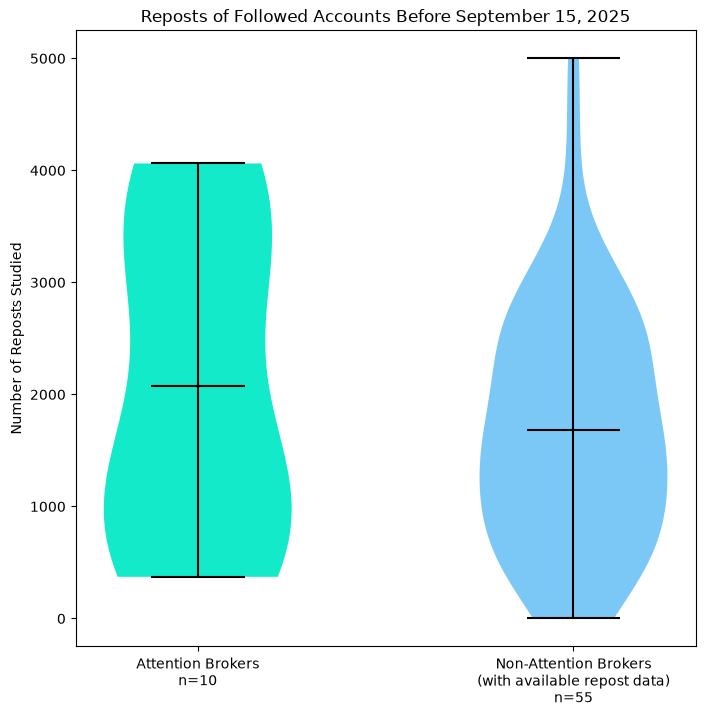

In [27]:
# Compare counts of reposts studied in final analysis (no significant difference)
plt.rcParams['figure.figsize'] = (8, 8)
plt.violinplot(
    [result_ab['n_reposts'], result_non['n_reposts']], 
    [1, 2],
    showmeans=True, 
    showextrema=True, 
    facecolor=['xkcd:aqua', 'xkcd:lightblue'],
    linecolor='black',
)

plt.title("Reposts of Followed Accounts Before September 15, 2025")
plt.xticks([1, 2], [f'Attention Brokers\nn={len(result_ab)}', f'Non-Attention Brokers\n(with available repost data)\nn={len(result_non)}'])
plt.ylabel("Number of Reposts Studied")
print(mannwhitneyu(result_ab['n_reposts'], result_non['n_reposts'], method='exact', alternative='greater'))
plt.savefig('./new_figs/reposts_studied.pdf')

MannwhitneyuResult(statistic=np.float64(196.0), pvalue=np.float64(0.07783017816672165))


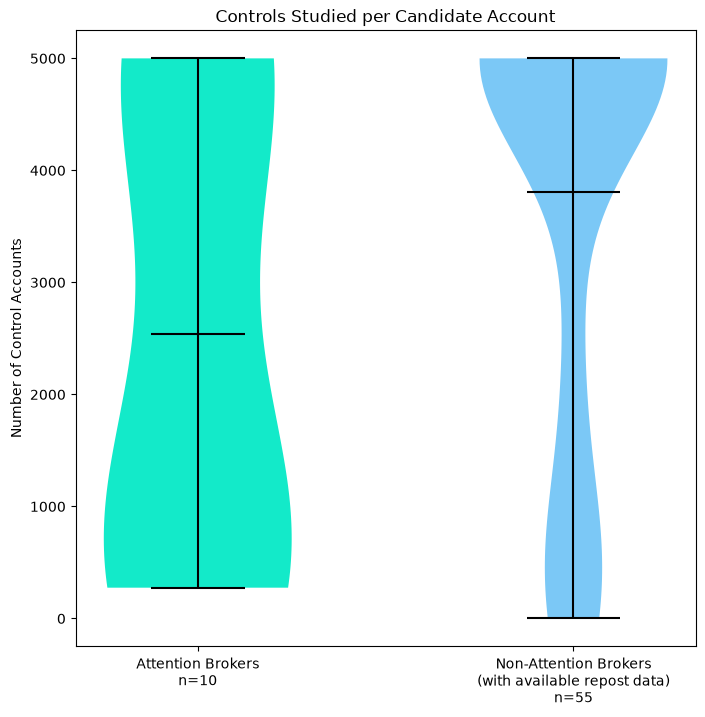

In [29]:
# Compare controls studied in each final analysis (no significant difference)

plt.rcParams['figure.figsize'] = (8, 8)
plt.violinplot(
    [result_ab['n_controls'], result_non['n_controls']], 
    [1, 2],
    showmeans=True, 
    showextrema=True, 
    facecolor=['xkcd:aqua', 'xkcd:lightblue'],
    linecolor='black',
)

plt.title("Controls Studied per Candidate Account")
plt.xticks([1, 2], [f'Attention Brokers\nn={len(result_ab)}', f'Non-Attention Brokers\n(with available repost data)\nn={len(result_non)}'])
plt.ylabel("Number of Control Accounts")
print(mannwhitneyu(result_ab['n_controls'], result_non['n_controls'], method='exact', alternative='less'))
plt.savefig('./new_figs/controls_studied.pdf')